# Étape 2 — Analyse des sentiments des conversations

## Notebook annoté

Ce notebook implémente un **classificateur de sentiments** sur des textes liés à la santé mentale, en suivant deux approches complémentaires :
- **Méthode supervisée** : Naive Bayes
- **Méthode non-supervisée** : K-Means

Le corpus d'entraînement utilisé est le dataset *Sentiment Analysis for Mental Health* (`Combined Data.csv`) disponible sur Kaggle.

---

## 1. Initialisation

Cette cellule importe l'ensemble des bibliothèques nécessaires au notebook :

| Bibliothèque | Rôle |
|---|---|
| `numpy`, `pandas` | Manipulation de données et tableaux numériques |
| `matplotlib`, `seaborn` | Visualisation (graphiques, camemberts) |
| `re` | Expressions régulières pour le nettoyage du texte |
| `WordCloud` | Génération de nuages de mots |
| `Counter` | Comptage de fréquences d'éléments |
| `sklearn` | Modèles ML, vectorisation, métriques d'évaluation |
| `nltk` | Traitement du langage naturel (tokenisation, stop-words) |

In [1]:
# importing libraries and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import nltk 
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

### 1.1 Chargement des données

Chargement du fichier `Combined Data.csv` dans un DataFrame pandas. Le paramètre `index_col=0` indique que la première colonne du CSV est l'index des lignes (et non une colonne de données à part entière). `df.head()` affiche les 5 premières lignes pour vérifier que le chargement s'est bien passé.

In [ ]:
df=pd.read_csv("../../data/combined_data.csv",index_col=0)
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


### 1.2 Mélange des données

Le dataset est **mélangé aléatoirement** (`sample(frac=1)`) avant tout traitement. Cela évite un biais si les données sont triées par ordre (ex : toutes les lignes d'une même classe regroupées). `random_state=42` garantit la **reproductibilité** : le même ordre sera obtenu à chaque exécution. `reset_index(drop=True)` remet les indices à 0, 1, 2… après le mélange.

In [3]:
# shuffle the rows, reset the indices
df = df.sample(frac = 1 ,random_state=42).reset_index(drop = True)
df

,statement,status
0,Just as the the title says. I feel like one is...,Depression
1,a blackened sky encroached tugging behind it m...,Depression
2,"It gives you insomnia, which in turn makes you...",Depression
3,"Hello all, I'm a new submitter to this channel...",Normal
4,Thank God the CB is over for Eid,Normal
...,...,...
53038,"I used to be a very confident, cheerful person...",Depression
53039,spanx except i missed last week s lee and now ...,Normal
53040,tl dr have been abused mentally and physically...,Depression
53041,do i sell the tutorial again?,Normal


### 1.3 Distribution des classes

`value_counts()` compte le nombre d'occurrences de chaque valeur unique dans la colonne `status` (les étiquettes de sentiment). Cette étape permet de vérifier si le dataset est **équilibré** ou non — un déséquilibre important entre classes peut impacter les performances des modèles.

In [4]:
# Count the occurrences of each status
label_counts = df['status'].value_counts()
print(label_counts)

status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


## 1.4 Visualisation de la distribution (camembert)

Ce graphique en camembert représente visuellement la **distribution des classes** calculée à l'étape précédente. `autopct='%1.1f%%'` affiche le pourcentage de chaque classe avec une décimale. La palette `pastel` de seaborn donne des couleurs douces et distinctes.

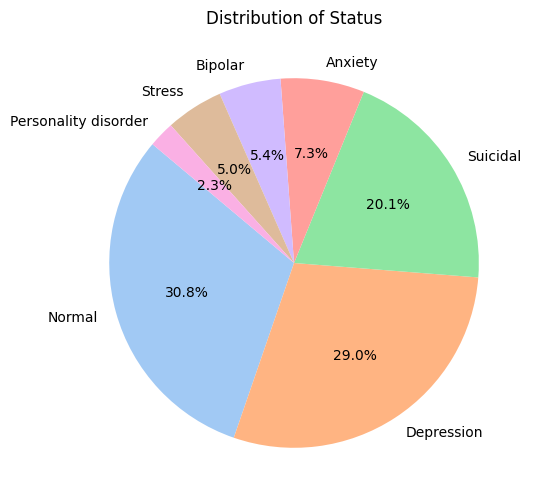

In [5]:
# Plot the pie chart
plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Status');

---
## 2. Nettoyage des données
### 2.1. Détection des valeurs manquantes

`isnull().sum()` compte le nombre de valeurs `NaN` (manquantes) dans chaque colonne. C'est une étape systématique de **contrôle qualité** : des valeurs manquantes dans la colonne `statement` provoqueraient des erreurs lors du nettoyage ou de la vectorisation.

In [6]:
# Missing values
df.isnull().sum()

statement    362
status         0
dtype: int64

### 2.2 Suppression des lignes vides

`dropna(axis=0)` supprime toutes les lignes contenant au moins une valeur manquante. Le paramètre `inplace=True` modifie directement le DataFrame sans créer une copie. Cette étape fait suite à la détection précédente.

In [7]:
# Drop rows with missing values
df.dropna(axis=0, inplace = True)
df.describe()

,statement,status
count,52681,52681
unique,51073,7
top,what do you mean?,Normal
freq,22,16343


### 2.3. Détection des étiquettes conflictuelles

Certains énoncés (`statement`) peuvent apparaître plusieurs fois dans le dataset avec des étiquettes (`status`) différentes — ce qui est contradictoire pour l'apprentissage. Cette cellule identifie ces cas en comptant le nombre de statuts distincts par énoncé. Si `nunique() != 1`, l'énoncé a plusieurs labels incompatibles.

In [8]:
# Count unique statuses for each statement
duplicate_labels = df.groupby('statement')['status'].nunique()

# Filter statements with more than one unique status
conflicting_statements = duplicate_labels[duplicate_labels != 1]

# Display problematic statements
print(f"Nombre de déclarations en conflit : {len(conflicting_statements)}")

Nombre de déclarations en conflit : 18


### 2.4 Suppression des étiquettes conflictuelles

On conserve uniquement les lignes dont l'énoncé possède **un seul statut cohérent** (`nunique() == 1`). Le `transform('nunique')` propage la valeur calculée par groupe à chaque ligne individuelle, ce qui permet le filtrage. `df.shape` est affiché pour confirmer la taille du dataset après nettoyage.

In [9]:
# Remove rows with confilicting labels, only keep statements that have a single consistent status
df = df[df.groupby('statement')['status'].transform('nunique') == 1]

print(df.shape)  # Check new dataset size

(52632, 2)


### 2.5. Nettoyage du texte (`cleaner`)

Cette fonction applique plusieurs **règles de nettoyage** via des expressions régulières :

| Règle | Exemple |
|---|---|
| Suppression des mentions `@utilisateur` | `@john` → supprimé |
| Suppression des URLs | `https://...` → supprimé |
| Suppression du HTML | `<br>`, `<b>` → supprimé |
| Détection des émoticônes textuels | `:)`, `;-P` → conservés en fin |
| Mise en minuscules + suppression des non-mots | `Hello!` → `hello` |

Les émoticônes sont extraits avant la suppression des non-mots, puis réajoutés à la fin du texte nettoyé.

In [10]:
# Defining a text cleaner
import re
def cleaner(text):
    text = re.sub(r'\s*@\w+', '', text)                            # remove words starting with @ 
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)            # remove URLs 
    text = re.sub(r'<[^>]*>', '', text)                            # remove all of the HTML markup
    #text = re.sub(r'\b\w\b', '', text)                             # remove single letters, I, a, ...
    emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text)  # find emoticons (emoji)
    text = (re.sub(r'[\W]+', ' ', text.lower()) + ' '.join(emoticons).replace('-', '')) 
    #  replace any non_word with space, lowercase words, add emojis at the end
    return text

### 2.6. Application du nettoyage

La fonction `cleaner` est appliquée à chaque ligne de la colonne `statement` via `.apply()`. `df.loc[:, 'statement']` est utilisé (plutôt que `df['statement']`) pour éviter un `SettingWithCopyWarning` de pandas lors de la modification en place. Le nombre de lignes restantes est affiché en sortie.

> **Note** : le bloc de détection de langue (`is_english`) est commenté. Il permettrait de ne conserver que les textes en anglais, mais alourdit le traitement. À réactiver si le corpus contient des textes multilingues.

In [11]:
# Cleaning the text
from langdetect import detect
from langdetect import DetectorFactory
DetectorFactory.seed = 42
df.loc[:, 'statement'] = df['statement'].apply(cleaner)
#def is_english(text):
 #   try:
  #      return detect(str(text)) == 'en'
   # except:
    #    return False  # si détection échoue on supprime la ligne
print(f"Après filtres : {df.shape[0]} lignes")
#df['statement'].apply(is_english)
#print(f"Après filtres : {df.shape[0]} lignes")
#only english text in base documents

Après filtres : 52632 lignes


### 2.7 Vérification d'un exemple nettoyé

Affiche le contenu de la ligne d'index 10 après nettoyage, pour vérifier visuellement que la fonction `cleaner` produit bien le résultat attendu (minuscules, sans ponctuation ni URL).

In [12]:
df['statement'][10]

'so i m sure all of you who live with anxiety do have your good day like the bad crippling anxiety come in wave which it doe for me when it s bad my anxiety is looking for any reason to latch it s self onto and make me believe that whatever the reason is that s what make me feel like shit when i have my good day and that thought or issue come to mind i m unfazed it s really fuckn annoying and i feel like it could make me make decision that i will for sure regret why is the brain so damn powerful and why do i have to live with this year of always feeling like shit it ha ruined my quality of life i am very grateful for my family and friend and i am grateful that i ve always had a good life but man i think of all the family trip event party anything fun ruined by my anxiety and sickness that come with it i feel for everyone that ha to go through this i m sorry guy and i hope one day we can be truly happy'

### 2.8 Séparation features / cible

On sépare le DataFrame en deux variables :
- `X` : les **features** (les énoncés textuels nettoyés, colonne `statement`)
- `y` : la **cible** (les étiquettes de sentiment, colonne `status`)

C'est la convention standard en scikit-learn avant tout découpage ou entraînement.

In [13]:
# Assigning features and target
X = df['statement']
y = df['status']

---
## 3. Entrainement du modèle
### 3.1 Découpage Train / Validation / Test

Mais alors pourquoi séparer les donnée en 3 et non 2 ?
En effet, il est courant de diviser les données en trois ensembles :
- **Ensemble d'entraînement (Train)** : utilisé pour entraîner le modèle.
- **Ensemble de validation (Validation)** : utilisé pour ajuster les hyperparamètres du modèle et éviter le surapprentissage (overfitting).
- **Ensemble de test (Test)** : utilisé pour évaluer la performance finale du modèle sur des données qu'il n'a jamais vues auparavant.
Cela permet d'avoir une évaluation plus fiable de la performance du modèle, car le test est effectué sur des données totalement indépendantes de celles utilisées pour l'entraînement et la validation.

Le paramètre `stratify=y` garantit que la **proportion de chaque classe** est identique dans les trois ensembles — indispensable en cas de déséquilibre des classes. `random_state=42` assure la reproductibilité.

In [14]:
# First split -> 60% train, 40% temp (validation + test)
# Second split -> 20% validation, 20% test (from the 40% temp)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train : {X_train.shape[0]} | Val : {X_val.shape[0]} | Test : {X_test.shape[0]}")

Train : 31579 | Val : 10526 | Test : 10527


### 3.2 Vérification de la distribution des classes

On s'assure que `stratify` a bien préservé les proportions dans les 3 ensembles.

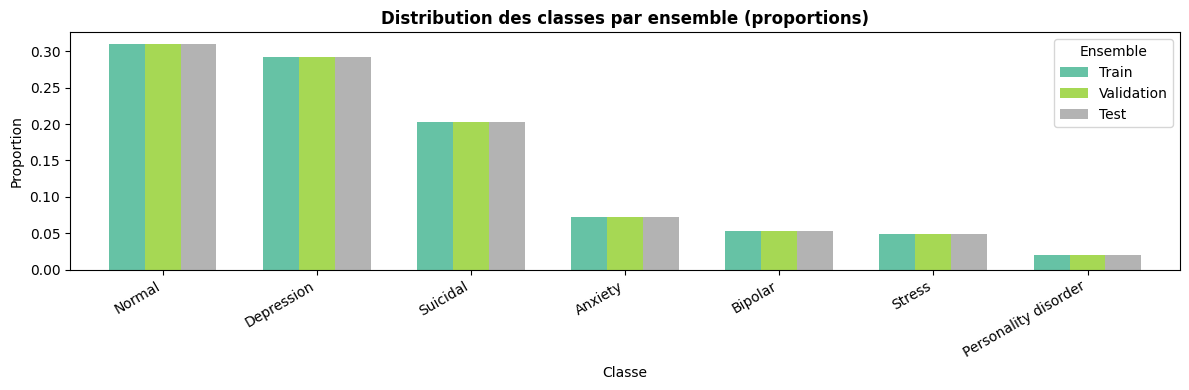

In [15]:
dist = pd.DataFrame({
    'Train'      : y_train.value_counts(normalize=True),
    'Validation' : y_val.value_counts(normalize=True),
    'Test'       : y_test.value_counts(normalize=True),
}).fillna(0)

ax = dist.plot(kind='bar', figsize=(12, 4), colormap='Set2', width=0.7)
ax.set_title('Distribution des classes par ensemble (proportions)', fontweight='bold')
ax.set_xlabel('Classe')
ax.set_ylabel('Proportion')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Ensemble')
plt.tight_layout()
plt.show()

### 3.3 Préambule tokenisation

- **Punkt** : modèle pré-entraîné de NLTK qui segmente le texte en mots tout en gérant les abréviations et la ponctuation (.,!,?).
Il gère aussi les abréviations (ex. `Dr.Smith` ne sera pas séparé en `Dr` puis `.` puis `Smith`)
- **Stop words** : mots très fréquents sans valeur sémantique (`the`, `is`, `and`…) qui sont retirés pour réduire le bruit.
- **Porter Stemmer** : algorithme qui réduit chaque mot à sa racine (`running` → `run`, `people` → `peopl`). Les formes produites ne sont pas toujours des mots réels, c'est un compromis connu.

#### 3.3.1 Fonction de tokenisation

La fonction `simple_tokenizer` applique en séquence :
1. **Tokenisation** : découpe la chaîne en liste de mots avec `word_tokenize`
2. **Filtrage des stop-words** : retire les mots sans valeur sémantique
3. **Stemming** : réduit chaque mot à sa racine avec le Porter Stemmer

L'exemple en fin de cellule (`"i.e., running faster..."`) permet de tester le comportement sur une phrase contenant une abréviation et une majuscule.

In [16]:
# Splitting text documents into tokens
import nltk 
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [17]:
# Download required NLTK data
nltk.download('punkt_tab')      # For punctuations used in word_tokenize 
nltk.download('stopwords')      # For stopword list

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\diogo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\diogo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
def simple_tokenizer(text):
    stop_words = set(stopwords.words('english'))    # Define stopwords (English)
    stemmer = PorterStemmer()                       # Initialize the stemmer
    tokens = word_tokenize(text)                    # Tokenize the text   
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words] # Remove stopwords   
    stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]             # Apply stemming
    return stemmed_tokens

# Example Usage
text = "i.e., running faster makes you stronger Mrs. Williams!"
print(simple_tokenizer(text))

['i.e.', ',', 'run', 'faster', 'make', 'stronger', 'mrs.', 'william', '!']


#### 3.3.2 Application de la tokenisation

La fonction `simple_tokenizer` est appliquée à chaque énoncé des ensembles train et test via `.apply()`. Chaque texte est ainsi transformé en une **liste de tokens** (racines de mots filtrés). Ces listes seront ensuite converties en vecteurs numériques par les vectoriseurs.

> **Attention**: Le temp d'exécution estimé peut aller de 1min à 2min30 !

In [19]:
# Application of tokenizer
X_train_tokens = X_train.apply(simple_tokenizer)
X_val_tokens   = X_val.apply(simple_tokenizer)
X_test_tokens  = X_test.apply(simple_tokenizer)

#### 3.3.3 Tokenisation du dataset complet

La tokenisation est également appliquée sur `X` entier (train + test confondus). Cette version `X_full` sera utilisée plus tard pour la vectorisation TF-IDF complète, notamment dans le contexte du déploiement sur le dataset principal (`train.csv`).

In [20]:
X_full=X.apply(simple_tokenizer)

#### 3.3.4. Aperçu des tokens

Affiche les 5 premières lignes tokenisées. Chaque cellule contient une liste de racines de mots. On peut y observer les effets du Porter Stemmer : `people` → `peopl`, `jealous` → `jealou`, etc. C'est le comportement attendu (voir discussion dans le notebook).

In [21]:
# View a few tokenised statements
X_train_tokens.head()

22977                                       [lemau, right]
22034    [think, peopl, see, think, worst, hate, presen...
5223     [stress, leav, anyon, ever, success, take, fml...
10113    [safe, sane, sober, check, good, support, netw...
22176    [well, coupl, month, recent, got, hit, anoth, ...
Name: statement, dtype: object

---
### 3.4. Bag-of-Words (BoW)

#### 3.4.1 Vectorisation BoW

Le **Bag-of-Words** crée une matrice où chaque ligne est un document et chaque colonne est un mot du vocabulaire. La valeur d'une cellule est le **nombre d'occurrences** du mot dans le document.

- `fit_transform` sur le train : construit le vocabulaire **et** transforme les données
- `transform` sur le test : applique le **même vocabulaire** sans le reconstruire (règle fondamentale pour éviter le data leakage)

Les tokens (listes) sont reconvertis en chaînes (`' '.join(x)`) car `CountVectorizer` attend des strings.

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

# Initializing a vectoriser
bow_vectorizer = CountVectorizer()

# Fitting to the bow-vectorizer — sur le train uniquement
X_train_bow = bow_vectorizer.fit_transform(X_train_tokens.apply(lambda x: ' '.join(x)))
X_val_bow   = bow_vectorizer.transform(X_val_tokens.apply(lambda x: ' '.join(x)))
X_test_bow  = bow_vectorizer.transform(X_test_tokens.apply(lambda x: ' '.join(x)))

#### 3.4.2. Aperçu du vocabulaire BoW

Affiche un extrait du vocabulaire appris par le `CountVectorizer` (tokens de rang 2000 à 2080). Permet de vérifier que les termes stockés sont bien des racines issues du stemming, et non des mots bruts.

In [23]:
# Show some of the vocabulary words
bow_vectorizer.get_feature_names_out()[2000:2080]  

array(['alamin', 'alan', 'alanin', 'alarm', 'alarmingli', 'alaska',
       'albanian', 'albeit', 'albert', 'alberta', 'albertson', 'album',
       'albumin', 'alc', 'alcahol', 'alcançar', 'alcapa', 'alchemist',
       'alchi', 'alchoh', 'alchohol', 'alchool', 'alco', 'alcohol',
       'alcoholi', 'alcol', 'alcoohol', 'alcool', 'ale', 'aleay', 'alec',
       'alejandralei', 'alement', 'alergi', 'alert', 'alessandrod',
       'alesso', 'alev', 'alevel', 'alex', 'alexa', 'alexandernl',
       'alexfost', 'alexlobaloba', 'alexrussin', 'alfredo', 'alg',
       'algebra', 'algn', 'algo', 'algonquin', 'algorithm', 'alguna',
       'alguno', 'alguém', 'alhaji', 'alhamdulilah', 'alhamdulillaaah',
       'alhamdulillah', 'alhasani', 'alhogol', 'ali', 'alia', 'alic',
       'aliceeu', 'aliceverheij', 'alielayu', 'alien', 'align', 'alik',
       'alimoni', 'alimwomba', 'alissa', 'alist', 'alittl', 'aliv',
       'alivei', 'aliveim', 'alivesomewher', 'alivesorri'], dtype=object)

#### 3.4.3 Dimensions de la matrice BoW

`X_train_bow.shape` retourne `(n_documents, n_features)` — le nombre de documents d'entraînement et la taille du vocabulaire. La matrice est **creuse** (sparse) : la plupart des cellules valent 0 car chaque document n'utilise qu'une infime fraction du vocabulaire total.

In [24]:
# View the dimensions of the BoW matrix and a small portion of its data
print(X_train_bow.shape)  # (num_samples: documents, num_features: unique tokens)
print(X_train_bow[:5])    # Shows first 5 rows (sparse format: only non-zero elements)

(31579, 31180)
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 110 stored elements and shape (5, 31180)>
  Coords	Values
  (0, 16090)	1
  (0, 23209)	1
  (1, 27344)	2
  (1, 20699)	1
  (1, 24119)	1
  (1, 30466)	1
  (1, 12582)	1
  (1, 21596)	1
  (1, 9428)	1
  (1, 13675)	1
  (1, 9870)	1
  (1, 16953)	1
  (1, 29051)	1
  (2, 26095)	2
  (2, 16035)	3
  (2, 2620)	1
  (2, 9716)	1
  (2, 26256)	1
  (2, 26764)	1
  (2, 10756)	1
  (2, 21735)	1
  (2, 16272)	1
  (2, 23089)	1
  (2, 21637)	1
  (2, 9269)	1
  :	:
  (4, 27881)	1
  (4, 29960)	1
  (4, 6737)	1
  (4, 18137)	1
  (4, 22576)	1
  (4, 11922)	1
  (4, 13055)	1
  (4, 2496)	1
  (4, 29833)	1
  (4, 7675)	1
  (4, 10563)	1
  (4, 1411)	1
  (4, 20787)	1
  (4, 13532)	2
  (4, 9098)	1
  (4, 9343)	1
  (4, 5252)	2
  (4, 9391)	1
  (4, 27620)	1
  (4, 12826)	1
  (4, 18256)	1
  (4, 3628)	1
  (4, 18831)	1
  (4, 22510)	1
  (4, 26140)	1


### 3.5 TF-IDF
#### 3.5.1 Vectorisation TF-IDF

Le **TF-IDF** (Term Frequency - Inverse Document Frequency) améliore le BoW en pondérant les mots : un mot fréquent dans un document mais rare dans le corpus global reçoit un score élevé, et inversement.

Paramètres utilisés :
- `ngram_range=(1, 2)` : prend en compte les **unigrammes** (mots seuls) et les **bigrammes** (paires de mots consécutifs)
- `max_df=0.8` : ignore les mots présents dans plus de 80% des documents (trop communs)
- `min_df=5` : ignore les mots présents dans moins de 5 documents (trop rares)

Même logique que BoW : `fit_transform` sur train uniquement, `transform` sur test et full.

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Define TfidfVectorizer with n-gram range
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.8, min_df=5)

# Apply TfidfVectorizer — fit sur le train uniquement
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_tokens.apply(lambda x: ' '.join(x)))
X_val_tfidf   = tfidf_vectorizer.transform(X_val_tokens.apply(lambda x: ' '.join(x)))
X_test_tfidf  = tfidf_vectorizer.transform(X_test_tokens.apply(lambda x: ' '.join(x)))
x_full_tfidf  = tfidf_vectorizer.transform(X_full.apply(lambda x: ' '.join(x)))

#### 3.5.2 Aperçu des features TF-IDF

Affiche un extrait des features apprises par le `TfidfVectorizer`. On peut y observer des **bigrammes** (ex: `feel anxious`, `mental health`) en plus des unigrammes, ce qui enrichit la représentation sémantique par rapport au BoW simple.

In [26]:
# View Feature Names (Words or N-grams)
print(tfidf_vectorizer.get_feature_names_out()[20100:20150])

['goal like' 'goal motiv' 'goal plan' 'goal seem' 'goal set' 'goal tri'
 'goal want' 'goal weight' 'god' 'god alway' 'god aw' 'god bless'
 'god creat' 'god damn' 'god exist' 'god feel' 'god forbid' 'god forgiv'
 'god forsaken' 'god fuck' 'god get' 'god given' 'god go' 'god god'
 'god hate' 'god help' 'god hope' 'god kill' 'god know' 'god let'
 'god live' 'god love' 'god make' 'god pleas' 'god punish' 'god realli'
 'god sake' 'god someth' 'god still' 'god take' 'god tell' 'god test'
 'god think' 'god tri' 'god want' 'god wish' 'god would' 'goddamn' 'goe'
 'goe away']


#### 3.5.3 Dimensions de la matrice TF-IDF

Vérifie la forme de la matrice TF-IDF et affiche les scores non-nuls des 3 premiers documents. Les valeurs sont des **flottants entre 0 et 1** (contrairement au BoW qui sont des entiers), car TF-IDF normalise les fréquences.

In [27]:
# See the dimensions of the BoW matrix and a small portion of its data
print(X_train_tfidf.shape) # (num_samples: documents, num_features: unique n-grams)
print(X_train_tfidf[:3])   # Shows nonzero TF-IDF scores in the first 3 documents

(31579, 56067)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 38 stored elements and shape (3, 56067)>
  Coords	Values
  (0, 40211)	1.0
  (1, 48261)	0.20868377649866512
  (1, 36143)	0.10948612641115503
  (1, 41579)	0.12591102104213575
  (1, 54877)	0.18582410832909743
  (1, 21809)	0.13724233450912454
  (1, 37745)	0.2905804861431099
  (1, 13657)	0.19626631333670994
  (1, 23905)	0.17832970452564795
  (1, 15081)	0.1776616948619775
  (1, 30144)	0.10762765337893847
  (1, 51463)	0.21556316543361637
  (1, 48520)	0.28031202631998314
  (1, 36413)	0.2816972103052587
  (1, 41775)	0.33977362819199974
  (1, 48657)	0.32801922227503
  (1, 15107)	0.3700884567824035
  (1, 30379)	0.33605661100387485
  (2, 45487)	0.22261162699359427
  (2, 26778)	0.32388603023517093
  (2, 3120)	0.08478777652819298
  (2, 14311)	0.09614251300906855
  (2, 45980)	0.14618361969506102
  (2, 46753)	0.0832005265513883
  (2, 17364)	0.23403379913343939
  (2, 38073)	0.1537127488066804
  (2, 27675)	0.05659581631374521
 

---
# **Fin de la partie commune ICI**

---

## Tuning de l'hyperparamètre alpha sur la validation

Avant d'entraîner le modèle final, on utilise l'ensemble de **validation** pour sélectionner le meilleur `alpha` (paramètre de lissage de Laplace) pour chaque variante. Cette étape remplace le choix arbitraire `alpha=0.1` du notebook original.

**Pourquoi ici ?** C'est le moment naturel : les matrices de features sont prêtes, et on veut fixer les hyperparamètres *avant* l'entraînement final — le test ne sera touché qu'une seule fois, après ce choix.

In [28]:
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
results = {'alpha': [], 'acc_bow': [], 'acc_tfidf': []}

for alpha in alphas:
    # BoW
    m_bow = MultinomialNB(alpha=alpha).fit(X_train_bow, y_train)
    acc_bow = accuracy_score(y_val, m_bow.predict(X_val_bow))

    # TF-IDF
    m_tfidf = MultinomialNB(alpha=alpha).fit(X_train_tfidf, y_train)
    acc_tfidf = accuracy_score(y_val, m_tfidf.predict(X_val_tfidf))

    results['alpha'].append(alpha)
    results['acc_bow'].append(acc_bow)
    results['acc_tfidf'].append(acc_tfidf)

df_results = pd.DataFrame(results)

best_alpha_bow   = df_results.loc[df_results['acc_bow'].idxmax(),   'alpha']
best_alpha_tfidf = df_results.loc[df_results['acc_tfidf'].idxmax(), 'alpha']

print(f"Meilleur alpha BoW   : {best_alpha_bow}  (val accuracy: {df_results['acc_bow'].max():.4f})")
print(f"Meilleur alpha TF-IDF: {best_alpha_tfidf} (val accuracy: {df_results['acc_tfidf'].max():.4f})")

Meilleur alpha BoW   : 0.1  (val accuracy: 0.6606)
Meilleur alpha TF-IDF: 0.05 (val accuracy: 0.6761)


> Alpha est le paramètre de lissage de Laplace pour le Naive Bayes Multinomial. 
Il ajoute une petite valeur aux comptes de mots pour éviter les probabilités nulles, 
améliorant ainsi la généralisation du modèle. 
Un alpha plus petit (0.05) indique moins de lissage, tandis qu'un alpha plus grand (0.1) 
indique plus de lissage.


### Courbe de validation — Accuracy selon alpha

Cette courbe montre l'évolution de l'accuracy sur la validation en fonction d'alpha pour les deux variantes, et confirme visuellement le choix retenu.

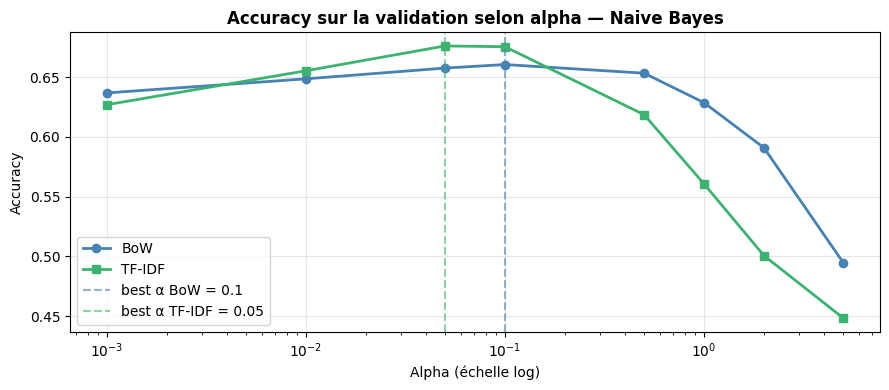

In [29]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.semilogx(df_results['alpha'], df_results['acc_bow'],
            marker='o', color='steelblue', linewidth=2, label='BoW')
ax.semilogx(df_results['alpha'], df_results['acc_tfidf'],
            marker='s', color='mediumseagreen', linewidth=2, label='TF-IDF')

ax.axvline(best_alpha_bow,   color='steelblue',      linestyle='--', alpha=0.6,
           label=f'best α BoW = {best_alpha_bow}')
ax.axvline(best_alpha_tfidf, color='mediumseagreen', linestyle='--', alpha=0.6,
           label=f'best α TF-IDF = {best_alpha_tfidf}')

ax.set_title('Accuracy sur la validation selon alpha — Naive Bayes', fontweight='bold')
ax.set_xlabel('Alpha (échelle log)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## Entraînement sur Naive Bayes BoW et TF-IDF


Deux modèles **Naive Bayes multinomial** sont entraînés en parallèle, l'un sur la représentation BoW et l'autre sur TF-IDF. Cela permettra de comparer l'impact de la vectorisation sur les performances.

> Ici on récupère les valeurs alpha `best_alpha_bow` et `best_alpha_tfidf` trouvés juste avant.

In [30]:
from sklearn.naive_bayes import MultinomialNB

# Initialize Naïve Bayes models with best alphas found on validation
nb_model_bow   = MultinomialNB(alpha=best_alpha_bow)
nb_model_tfidf = MultinomialNB(alpha=best_alpha_tfidf)

# Train Naïve Bayes on the bag-of-words features
nb_model_bow.fit(X_train_bow, y_train)

# Train Naïve Bayes on the TF-IDF features
nb_model_tfidf.fit(X_train_tfidf, y_train)

,alpha,np.float64(0.05)
,force_alpha,True
,fit_prior,True
,class_prior,None


---
## Prédictions Naive Bayes

Les deux modèles génèrent leurs **prédictions** sur l'ensemble de test. Les vecteurs `nb_predictions_bow` et `nb_predictions_tfidf` contiennent les étiquettes prédites pour chaque document du test set. Ils seront évalués dans la cellule suivante.

In [31]:
# Naïve Bayes
nb_predictions_bow = nb_model_bow.predict(X_test_bow)
nb_predictions_tfidf = nb_model_tfidf.predict(X_test_tfidf)

---
## Évaluation des modèles supervisés

La fonction `evaluate` centralise toutes les métriques d'évaluation demandées par le cahier des charges :

| Métrique | Description |
|---|---|
| **Accuracy** | Proportion de prédictions correctes |
| **MSE** | Erreur quadratique moyenne sur les labels encodés |
| **R²** | Coefficient de détermination (peu pertinent en classification, mais inclus) |
| **Classification report** | Précision, rappel et F1-score par classe |
| **Matrice de confusion** | Visualisation des erreurs par classe |

Un `LabelEncoder` est utilisé pour convertir les étiquettes textuelles en entiers, requis par certaines métriques. La fonction est ensuite appelée pour évaluer les deux variantes Naive Bayes.


══════════════════════════════════════════════════
  Naïve Bayes — BoW
══════════════════════════════════════════════════
  Accuracy : 0.6666
  MSE      : 3.0897
  R²       : 0.0296

                      precision    recall  f1-score   support

             Anxiety       0.68      0.73      0.71       767
             Bipolar       0.60      0.76      0.68       556
          Depression       0.57      0.61      0.59      3076
              Normal       0.92      0.70      0.80      3268
Personality disorder       0.50      0.56      0.53       215
              Stress       0.52      0.43      0.47       516
            Suicidal       0.60      0.72      0.65      2129

            accuracy                           0.67     10527
           macro avg       0.63      0.65      0.63     10527
        weighted avg       0.69      0.67      0.67     10527



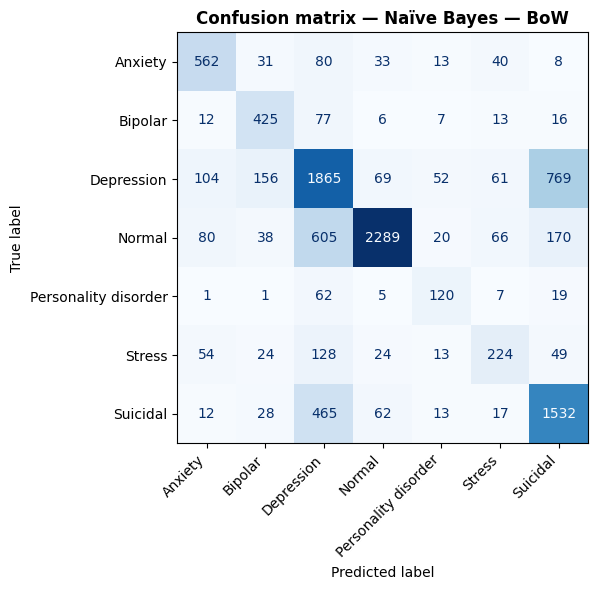


══════════════════════════════════════════════════
  Naïve Bayes — TF-IDF
══════════════════════════════════════════════════
  Accuracy : 0.6875
  MSE      : 2.8781
  R²       : 0.0961

                      precision    recall  f1-score   support

             Anxiety       0.76      0.71      0.73       767
             Bipolar       0.82      0.58      0.68       556
          Depression       0.54      0.77      0.63      3076
              Normal       0.90      0.77      0.83      3268
Personality disorder       0.97      0.29      0.45       215
              Stress       0.83      0.27      0.41       516
            Suicidal       0.65      0.60      0.62      2129

            accuracy                           0.69     10527
           macro avg       0.78      0.57      0.62     10527
        weighted avg       0.73      0.69      0.69     10527



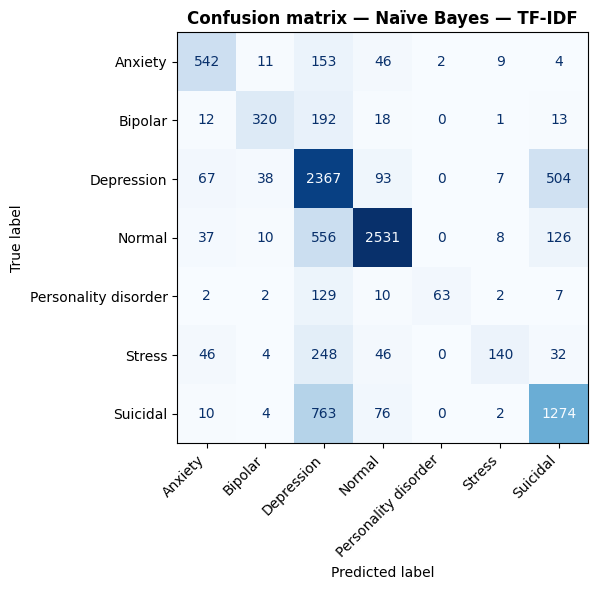

In [32]:
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             mean_squared_error, r2_score,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

le = LabelEncoder()
le.fit(y_train)
y_test_enc = le.transform(y_test)

def evaluate(name, y_true_enc, y_pred_labels):
    """Print accuracy, MSE, R² and plot confusion matrix."""
    y_pred_enc = le.transform(y_pred_labels)

    acc = accuracy_score(y_true_enc, y_pred_enc)
    mse = mean_squared_error(y_true_enc, y_pred_enc)
    r2  = r2_score(y_true_enc, y_pred_enc)

    print(f"\n{'═'*50}")
    print(f"  {name}")
    print(f"{'═'*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  MSE      : {mse:.4f}")
    print(f"  R²       : {r2:.4f}")
    print(f"\n{classification_report(y_true_enc, y_pred_enc, target_names=le.classes_)}")

    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_true_enc, y_pred_enc,
        display_labels=le.classes_,
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f"Confusion matrix — {name}", fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return acc, mse, r2, y_pred_enc


# Evaluate both Naive Bayes variants
acc_bow,   mse_bow,   r2_bow,   enc_bow   = evaluate("Naïve Bayes — BoW",    y_test_enc, nb_predictions_bow)
acc_tfidf, mse_tfidf, r2_tfidf, enc_tfidf = evaluate("Naïve Bayes — TF-IDF", y_test_enc, nb_predictions_tfidf)

---
## Méthode non-supervisée — K-Means avec TF-IDF et Word2Vec

Cette grande cellule implémente l'approche non-supervisée. Elle est structurée en plusieurs fonctions :

- `run_kmeans_analysis(X, ...)` — Sélection du meilleur k
  + Applique une **réduction dimensionnelle SVD** (Truncated SVD) si la matrice est creuse ou grande (ce qui est le cas avec TF-IDF). SVD projette les données dans un espace de 100 dimensions en conservant le maximum de variance.
  + Teste différentes valeurs de `k` (de 2 à 15 par défaut) avec `MiniBatchKMeans` (version efficace de K-Means pour grands datasets).
- Pour chaque `k`, calcule :
  + **WCSS** (Within-Cluster Sum of Squares / inertie) : méthode du coude
  + **Score silhouette cosinus** : mesure la séparation entre clusters
- Trace les deux courbes et retourne le `k` maximisant la silhouette.

- `kmeans_predict(X_new, km_model, cluster_to_label)` — Prédiction
Assigne une étiquette à chaque nouveau document en utilisant la correspondance cluster → label construite pendant l'entraînement.

- `train_eval_kmeans(name, ...)` — Pipeline complet
Orchestre le pipeline entier :
  1. Réduction SVD sur train, puis projection test
  2. Appel à `run_kmeans_analysis` pour trouver le meilleur k
  3. Entraînement du modèle final avec ce k (avec un plancher à `n_classes` pour garantir qu'il y a au moins un cluster par classe)
  4. **Mapping cluster → label par vote majoritaire** : chaque cluster prend l'étiquette la plus fréquente parmi ses membres d'entraînement. Un algorithme glouton évite que plusieurs clusters se mappent à la même classe.
  5. Prédiction et évaluation via `evaluate()`

Les deux variantes (TF-IDF et BoW) sont ensuite lancées.

> **Attention**, il ne faut pas oublier de normaliser les données !  
**Pourquoi ?** K-Means minimise la distance euclidienne entre les points 
et les centroïdes. 
Or les vecteurs TF-IDF ou BoW ont des normes très différentes selon la longueur des textes — un énoncé long aura mécaniquement des valeurs plus élevées qu'un énoncé court, 
ce qui biaise le clustering indépendamment du contenu sémantique


> Il est important de ne pas faire de fit sur les données de validation et de test pour éviter le **data leakage**.  
En effet, si nous appliquons un fit sur ces ensembles, nous risquons d'introduire des informations provenant de ces ensembles dans notre modèle, ce qui fausserait l'évaluation de sa performance réelle sur des données jamais vues auparavant. Par conséquent, nous devons uniquement appliquer les transformations (comme le fit) sur les données d'entraînement, puis utiliser ces transformations pour transformer les données de validation et de test sans les ajuster à nouveau.

[TF-IDF] SVD → (31579, 100) (var: 11.14%)
[TF-IDF] k= 2 | WCSS=26,476 | sil(val)=0.0715
[TF-IDF] k= 3 | WCSS=26,088 | sil(val)=0.0170
[TF-IDF] k= 4 | WCSS=25,680 | sil(val)=0.0230
[TF-IDF] k= 5 | WCSS=25,344 | sil(val)=0.0253
[TF-IDF] k= 6 | WCSS=25,281 | sil(val)=0.0191
[TF-IDF] k= 7 | WCSS=25,465 | sil(val)=0.0137
[TF-IDF] k= 8 | WCSS=25,211 | sil(val)=0.0180
[TF-IDF] k= 9 | WCSS=24,881 | sil(val)=0.0194
[TF-IDF] k=10 | WCSS=24,567 | sil(val)=0.0194
[TF-IDF] k=11 | WCSS=24,734 | sil(val)=0.0123
[TF-IDF] k=12 | WCSS=24,277 | sil(val)=0.0402
[TF-IDF] k=13 | WCSS=24,109 | sil(val)=0.0362
[TF-IDF] k=14 | WCSS=24,046 | sil(val)=0.0387
[TF-IDF] k=15 | WCSS=23,934 | sil(val)=0.0381


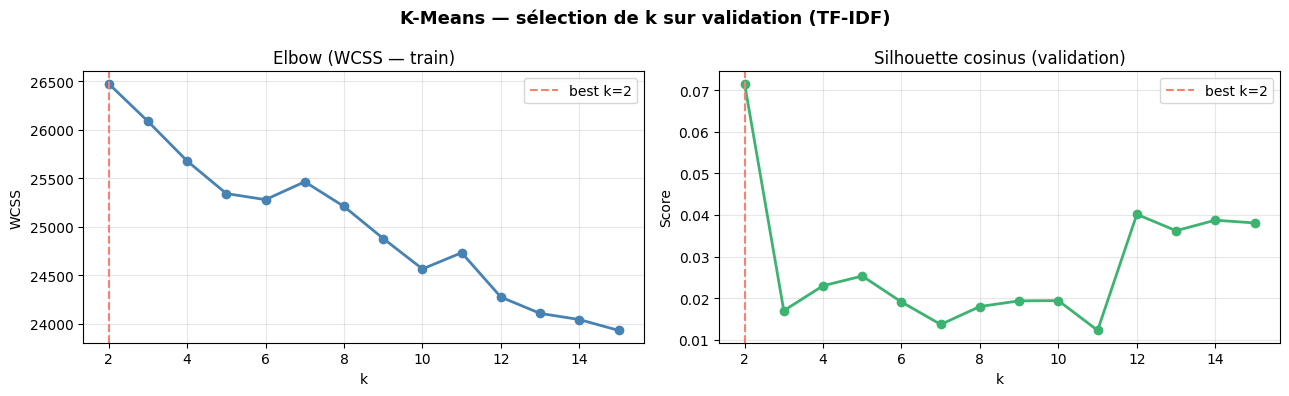


[TF-IDF] Meilleur k retenu : 7

[TF-IDF] Cluster → label mapping :
  cluster  0 → Stress                    (purity: 33.76%)
  cluster  1 → Depression                (purity: 85.04%)
  cluster  2 → Suicidal                  (purity: 47.89%)
  cluster  3 → Anxiety                   (purity: 55.70%)
  cluster  4 → Normal                    (purity: 60.91%)
  cluster  5 → Bipolar                   (purity: 35.49%)
  cluster  6 → Personality disorder      (purity: 30.08%)

══════════════════════════════════════════════════
  K-Means (k=7) — TF-IDF
══════════════════════════════════════════════════
  Accuracy : 0.4636
  MSE      : 5.2866
  R²       : -0.6603

                      precision    recall  f1-score   support

             Anxiety       0.62      0.21      0.31       767
             Bipolar       0.36      0.53      0.43       556
          Depression       0.88      0.13      0.23      3076
              Normal       0.62      0.87      0.72      3268
Personality disorder     

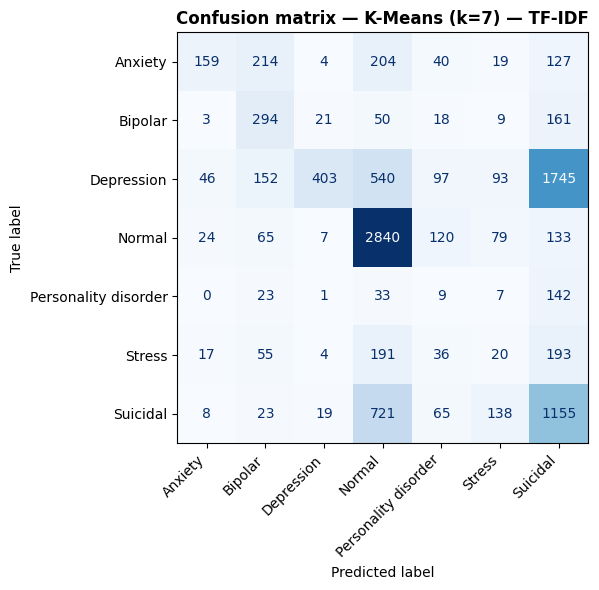


[TF-IDF] Purity : 0.6253 | ARI : 0.2481
[BoW] SVD → (31579, 100) (var: 78.47%)
[BoW] k= 2 | WCSS=26,145 | sil(val)=0.0512
[BoW] k= 3 | WCSS=25,500 | sil(val)=0.0368
[BoW] k= 4 | WCSS=25,004 | sil(val)=0.0472
[BoW] k= 5 | WCSS=24,804 | sil(val)=0.0508
[BoW] k= 6 | WCSS=24,619 | sil(val)=0.0512
[BoW] k= 7 | WCSS=24,390 | sil(val)=0.0344
[BoW] k= 8 | WCSS=24,183 | sil(val)=0.0347
[BoW] k= 9 | WCSS=23,809 | sil(val)=0.0492
[BoW] k=10 | WCSS=23,684 | sil(val)=0.0337
[BoW] k=11 | WCSS=23,720 | sil(val)=0.0259
[BoW] k=12 | WCSS=23,125 | sil(val)=0.0531
[BoW] k=13 | WCSS=23,184 | sil(val)=0.0489
[BoW] k=14 | WCSS=23,137 | sil(val)=0.0314
[BoW] k=15 | WCSS=22,794 | sil(val)=0.0483


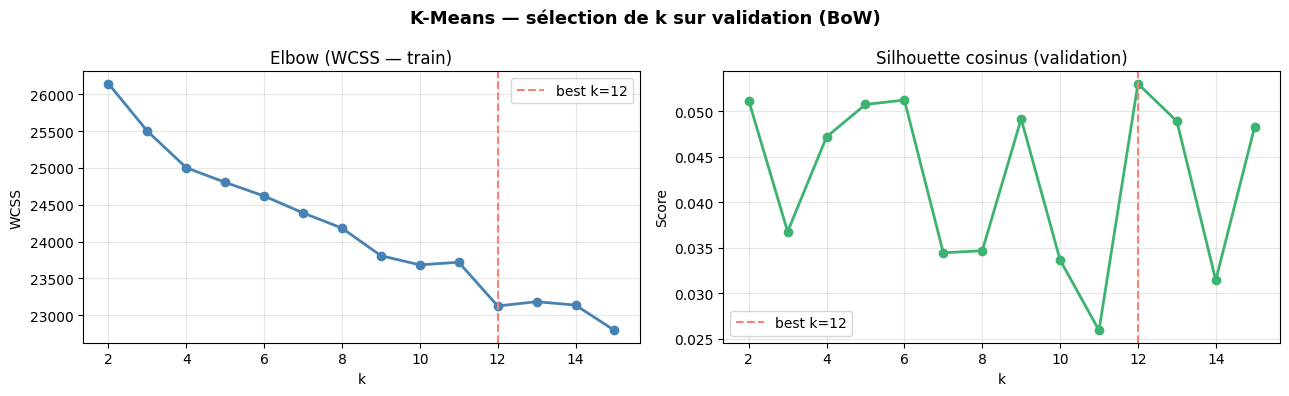


[BoW] Meilleur k retenu : 12

[BoW] Cluster → label mapping :
  cluster  0 → Depression                (purity: 31.51%)
  cluster  1 → Depression                (purity: 29.28%)
  cluster  2 → Bipolar                   (purity: 44.66%)
  cluster  3 → Suicidal                  (purity: 71.33%)
  cluster  4 → Normal                    (purity: 34.70%)
  cluster  5 → Depression                (purity: 28.97%)
  cluster  6 → Normal                    (purity: 88.31%)
  cluster  7 → Anxiety                   (purity: 48.67%)
  cluster  8 → Normal                    (purity: 33.84%)
  cluster  9 → Personality disorder      (purity: 36.04%)
  cluster 10 → Stress                    (purity: 41.62%)
  cluster 11 → Depression                (purity: 83.60%)

══════════════════════════════════════════════════
  K-Means (k=12) — BoW
══════════════════════════════════════════════════
  Accuracy : 0.2220
  MSE      : 6.8761
  R²       : -1.1596

                      precision    recall  f1-score  

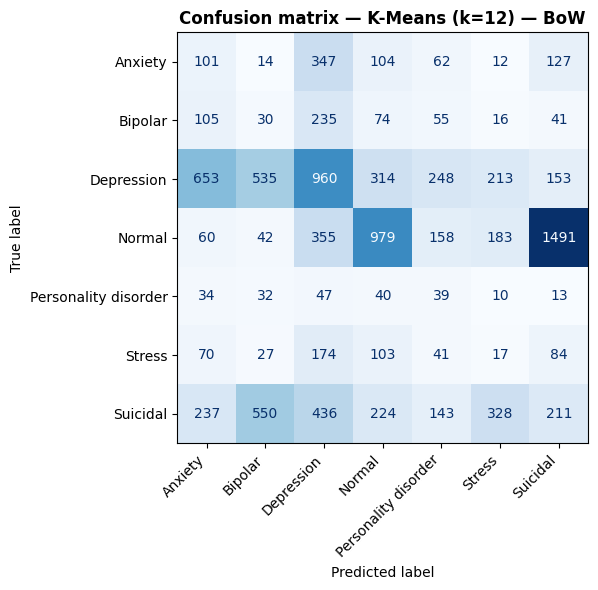


[BoW] Purity : 0.3614 | ARI : 0.1085


In [33]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import normalize
import scipy.sparse as sp
from collections import Counter


def kmeans_predict(X_new, km_model, cluster_to_label):
    """Assign labels to new samples using a trained K-Means + majority-vote map."""
    cluster_ids = km_model.predict(X_new)
    return np.array([cluster_to_label[c] for c in cluster_ids])


def train_eval_kmeans(name, X_tr, X_val, X_te, y_tr, y_val, y_te,
                      n_svd_components=100, k_range=(2, 15)):

    n_classes = y_tr.nunique()

    # ── Step 1: SVD + normalisation L2 (fit sur train uniquement) ───────────
    if sp.issparse(X_tr) or X_tr.shape[1] > 500:
        n_comp = min(n_svd_components, X_tr.shape[1] - 1)
        svd = TruncatedSVD(n_components=n_comp, random_state=42)
        X_tr_red  = normalize(svd.fit_transform(X_tr),  norm='l2')
        X_val_red = normalize(svd.transform(X_val),     norm='l2')
        X_te_red  = normalize(svd.transform(X_te),      norm='l2')
        print(f"[{name}] SVD → {X_tr_red.shape} "
              f"(var: {svd.explained_variance_ratio_.sum():.2%})")
    else:
        svd = None
        X_tr_red  = normalize(X_tr,  norm='l2')
        X_val_red = normalize(X_val, norm='l2')
        X_te_red  = normalize(X_te,  norm='l2')

    # ── Step 2: Sélection du meilleur k sur la VALIDATION ───────────────────
    best_k, best_sil = None, -1
    wcss_list, sil_list, valid_k = [], [], []

    for k in range(k_range[0], k_range[1] + 1):
        try:
            km = MiniBatchKMeans(n_clusters=k, random_state=42,
                                 batch_size=1000, n_init=10)
            km.fit(X_tr_red)                        # fit sur train
            val_labels = km.predict(X_val_red)      # évaluation sur val

            if len(set(val_labels)) < 2:
                continue

            sil = silhouette_score(X_val_red, val_labels, metric='cosine',
                                   sample_size=min(2000, X_val_red.shape[0]),
                                   random_state=42)
            valid_k.append(k)
            wcss_list.append(km.inertia_)
            sil_list.append(sil)
            print(f"[{name}] k={k:2d} | WCSS={km.inertia_:,.0f} | sil(val)={sil:.4f}")

            if sil > best_sil:
                best_sil, best_k = sil, k
        except Exception as e:
            print(f"[{name}] k={k} failed: {e}")

    # Courbes elbow + silhouette sur la validation
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"K-Means — sélection de k sur validation ({name})",
                 fontsize=13, fontweight='bold')
    axes[0].plot(valid_k, wcss_list, marker='o', color='steelblue', linewidth=2)
    axes[0].axvline(best_k, color='salmon', linestyle='--', label=f'best k={best_k}')
    axes[0].set_title("Elbow (WCSS — train)"); axes[0].set_xlabel("k")
    axes[0].set_ylabel("WCSS"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(valid_k, sil_list, marker='o', color='mediumseagreen', linewidth=2)
    axes[1].axvline(best_k, color='salmon', linestyle='--', label=f'best k={best_k}')
    axes[1].set_title("Silhouette cosinus (validation)"); axes[1].set_xlabel("k")
    axes[1].set_ylabel("Score"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # Plancher à n_classes pour garantir au moins un cluster par classe
    best_k = max(best_k, n_classes)
    print(f"\n[{name}] Meilleur k retenu : {best_k}")

    # ── Step 3: Entraînement final sur train ─────────────────────────────────
    km_final = MiniBatchKMeans(n_clusters=best_k, random_state=42,
                               batch_size=1000, n_init=10)
    train_clusters = km_final.fit_predict(X_tr_red)

    # ── Step 4: Mapping cluster → label par vote majoritaire ─────────────────
    cluster_purity = {}
    for cid in range(best_k):
        mask = train_clusters == cid
        if mask.sum() == 0:
            continue
        labels_in = y_tr.values[mask]
        top_label, top_count = Counter(labels_in).most_common(1)[0]
        cluster_purity[cid] = (top_label, top_count, top_count / mask.sum())

    cluster_to_label = {}
    assigned_labels  = {}
    for cid, (lbl, cnt, pur) in sorted(cluster_purity.items(),
                                        key=lambda x: -x[1][2]):
        if lbl not in assigned_labels:
            cluster_to_label[cid] = lbl
            assigned_labels[lbl]  = cid
        else:
            labels_in = y_tr.values[train_clusters == cid]
            for alt_lbl, _ in Counter(labels_in).most_common():
                if alt_lbl not in assigned_labels:
                    cluster_to_label[cid] = alt_lbl
                    assigned_labels[alt_lbl] = cid
                    break
            else:
                cluster_to_label[cid] = Counter(labels_in).most_common(1)[0][0]

    print(f"\n[{name}] Cluster → label mapping :")
    for cid, lbl in sorted(cluster_to_label.items()):
        pur = cluster_purity.get(cid, (None, None, 0))[2]
        print(f"  cluster {cid:2d} → {lbl:25s} (purity: {pur:.2%})")

    # ── Step 5: Prédiction et évaluation sur TEST ────────────────────────────
    y_pred_labels = kmeans_predict(X_te_red, km_final, cluster_to_label)
    evaluate(f"K-Means (k={best_k}) — {name}", y_test_enc, y_pred_labels)

    # Métriques supplémentaires : Purity globale + ARI
    y_te_enc = le.transform(y_te)
    y_pred_enc = le.transform(y_pred_labels)

    purity = np.sum(np.max(
        np.array([[np.sum((y_te_enc == c) & (y_pred_enc == p))
                   for p in np.unique(y_pred_enc)]
                  for c in np.unique(y_te_enc)]), axis=1)) / len(y_te_enc)

    ari = adjusted_rand_score(y_te_enc, y_pred_enc)
    print(f"\n[{name}] Purity : {purity:.4f} | ARI : {ari:.4f}")


# ── Lancement ────────────────────────────────────────────────────────────────
train_eval_kmeans("TF-IDF",
                  X_train_tfidf, X_val_tfidf, X_test_tfidf,
                  y_train, y_val, y_test)

train_eval_kmeans("BoW",
                  X_train_bow, X_val_bow, X_test_bow,
                  y_train, y_val, y_test)

Tuning de l'hyperparamètre C sur la validation — LinearSVC
Avant d'entraîner le modèle final, on utilise l'ensemble de **validation** pour
sélectionner le meilleur `C` (paramètre de régularisation) pour chaque variante.
Cette étape remplace le choix arbitraire d'une valeur par défaut.
**Pourquoi C ?** C contrôle le compromis entre marge maximale et erreurs de
classification :
- Un C faible → forte régularisation, grande marge, modèle plus simple
(risque de sous-apprentissage)
- Un C élevé → faible régularisation, marge étroite, modèle très ajusté
 (risque de surapprentissage)

In [34]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

C_values = [0.01, 0.1, 1]
results_svc = {'C': [], 'acc_bow': [], 'acc_tfidf': []}

for C in C_values:
    # BoW
    m_bow = LinearSVC(C=C, max_iter=2000, random_state=42).fit(X_train_bow, y_train)
    acc_bow = accuracy_score(y_val, m_bow.predict(X_val_bow))

    # TF-IDF
    m_tfidf = LinearSVC(C=C, max_iter=2000, random_state=42).fit(X_train_tfidf, y_train)
    acc_tfidf = accuracy_score(y_val, m_tfidf.predict(X_val_tfidf))

    results_svc['C'].append(C)
    results_svc['acc_bow'].append(acc_bow)
    results_svc['acc_tfidf'].append(acc_tfidf)

df_results_svc = pd.DataFrame(results_svc)

best_C_bow   = df_results_svc.loc[df_results_svc['acc_bow'].idxmax(),   'C']
best_C_tfidf = df_results_svc.loc[df_results_svc['acc_tfidf'].idxmax(), 'C']

print(f"Meilleur C BoW   : {best_C_bow}  (val accuracy: {df_results_svc['acc_bow'].max():.4f})")
print(f"Meilleur C TF-IDF: {best_C_tfidf} (val accuracy: {df_results_svc['acc_tfidf'].max():.4f})")

Meilleur C BoW   : 0.1  (val accuracy: 0.7309)
Meilleur C TF-IDF: 1.0 (val accuracy: 0.7386)


Courbe de validation — Accuracy selon C
Cette courbe montre l'évolution de l'accuracy sur la validation en fonction de C
pour les deux variantes, et confirme visuellement le choix retenu.

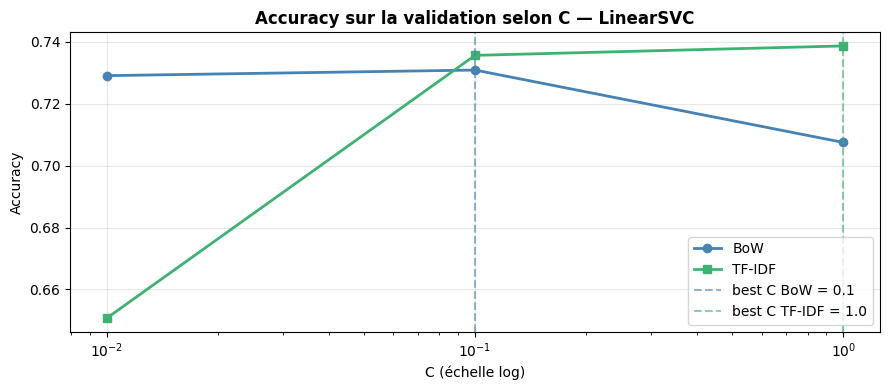

In [35]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.semilogx(df_results_svc['C'], df_results_svc['acc_bow'],
            marker='o', color='steelblue', linewidth=2, label='BoW')
ax.semilogx(df_results_svc['C'], df_results_svc['acc_tfidf'],
            marker='s', color='mediumseagreen', linewidth=2, label='TF-IDF')

ax.axvline(best_C_bow,   color='steelblue',      linestyle='--', alpha=0.6,
           label=f'best C BoW = {best_C_bow}')
ax.axvline(best_C_tfidf, color='mediumseagreen', linestyle='--', alpha=0.6,
           label=f'best C TF-IDF = {best_C_tfidf}')

ax.set_title('Accuracy sur la validation selon C — LinearSVC', fontweight='bold')
ax.set_xlabel('C (échelle log)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Entraînement sur LinearSVC BoW et TF-IDF
Deux modèles **LinearSVC** sont entraînés en parallèle, l'un sur la représentation
BoW et l'autre sur TF-IDF. Cela permettra de comparer l'impact de la vectorisation sur les performances, comme fait pour le Naive Bayes.
> Ici on récupère les valeurs `best_C_bow` et `best_C_tfidf` trouvées juste avant.

In [36]:
from sklearn.svm import LinearSVC

# Initialize LinearSVC models with best C found on validation
svc_model_bow   = LinearSVC(C=best_C_bow,   max_iter=2000, random_state=42)
svc_model_tfidf = LinearSVC(C=best_C_tfidf, max_iter=2000, random_state=42)

# Train LinearSVC on the bag-of-words features
svc_model_bow.fit(X_train_bow, y_train)

# Train LinearSVC on the TF-IDF features
svc_model_tfidf.fit(X_train_tfidf, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,np.float64(1.0)
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [37]:
# LinearSVC predictions
svc_predictions_bow   = svc_model_bow.predict(X_test_bow)
svc_predictions_tfidf = svc_model_tfidf.predict(X_test_tfidf)

La même fonction `evaluate` est réutilisée pour assurer une comparaison directe
avec les résultats Naive Bayes. Les métriques produites sont identiques :


══════════════════════════════════════════════════
  LinearSVC — BoW
══════════════════════════════════════════════════
  Accuracy : 0.7359
  MSE      : 2.8412
  R²       : 0.1077

                      precision    recall  f1-score   support

             Anxiety       0.77      0.73      0.75       767
             Bipolar       0.79      0.73      0.76       556
          Depression       0.71      0.65      0.68      3076
              Normal       0.84      0.95      0.89      3268
Personality disorder       0.68      0.59      0.63       215
              Stress       0.52      0.46      0.49       516
            Suicidal       0.63      0.63      0.63      2129

            accuracy                           0.74     10527
           macro avg       0.70      0.68      0.69     10527
        weighted avg       0.73      0.74      0.73     10527



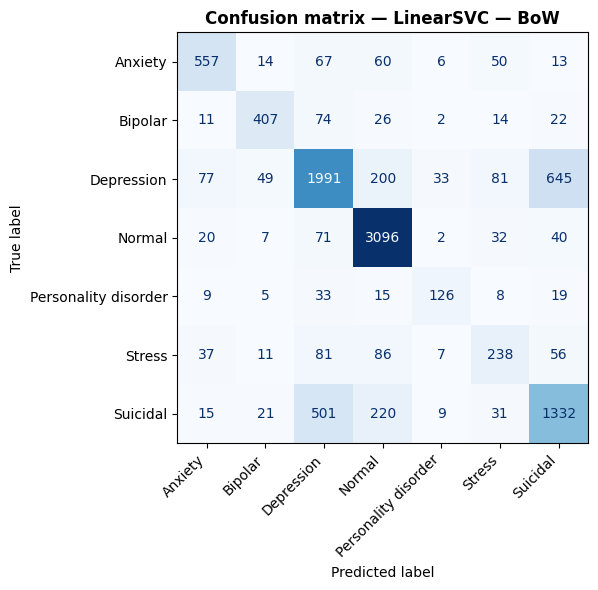


══════════════════════════════════════════════════
  LinearSVC — TF-IDF
══════════════════════════════════════════════════
  Accuracy : 0.7477
  MSE      : 2.7078
  R²       : 0.1496

                      precision    recall  f1-score   support

             Anxiety       0.81      0.79      0.80       767
             Bipolar       0.86      0.71      0.78       556
          Depression       0.68      0.70      0.69      3076
              Normal       0.85      0.94      0.89      3268
Personality disorder       0.86      0.56      0.68       215
              Stress       0.68      0.46      0.55       516
            Suicidal       0.63      0.61      0.62      2129

            accuracy                           0.75     10527
           macro avg       0.77      0.68      0.71     10527
        weighted avg       0.74      0.75      0.74     10527



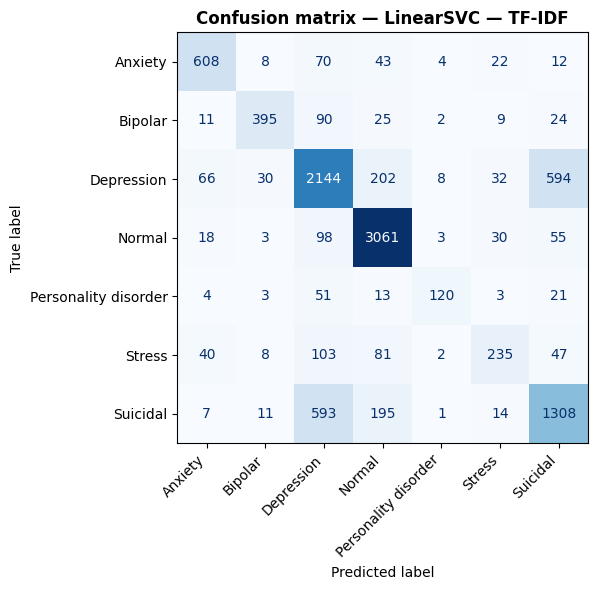

In [38]:
# Evaluate both LinearSVC variants
acc_svc_bow,   mse_svc_bow,   r2_svc_bow,   enc_svc_bow   = evaluate("LinearSVC — BoW",    y_test_enc, svc_predictions_bow)
acc_svc_tfidf, mse_svc_tfidf, r2_svc_tfidf, enc_svc_tfidf = evaluate("LinearSVC — TF-IDF", y_test_enc, svc_predictions_tfidf)